[3.45575094 0.69711036 0.05930983]


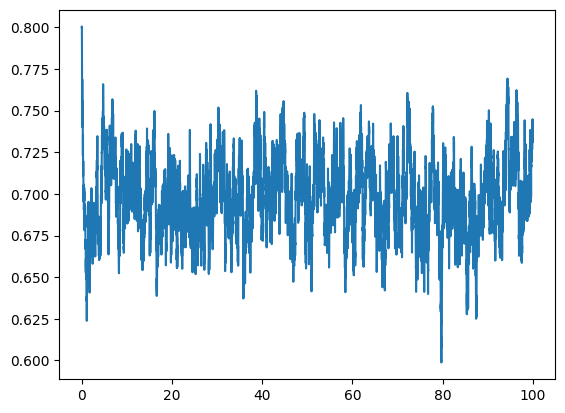

In [23]:
from ou_noise import ou
import numpy
import matplotlib.pyplot as plt


t = numpy.arange(0, 100, 0.01)
# simulate a path of the OU process on a given grid t, starting with x_0 = 0.8
x = ou.path(0.8, t, 3.0, 0.7, 0.06)                                           
plt.plot(t,x)

params = ou.mle(t, x)
print(params)

In [24]:
import numpy as np

def calibrate_ou_regular(t, x):
    """Estimate Ornstein–Uhlenbeck parameters from equally spaced data."""
    t = np.asarray(t)
    x = np.asarray(x, float)
    dt = float(np.mean(np.diff(t)))
    x_lag, x_lead = x[:-1], x[1:]
    X = np.vstack([np.ones_like(x_lag), x_lag]).T
    a_hat, b_hat = np.linalg.lstsq(X, x_lead, rcond=None)[0]
    resid = x_lead - (a_hat + b_hat * x_lag)
    resid_var = np.var(resid, ddof=1)

    b = b_hat
    kappa = -np.log(b) / dt
    mu = a_hat / (1.0 - b)
    sigma = np.sqrt(2.0 * kappa * resid_var / (1.0 - np.exp(-2.0*kappa*dt)))

    half_life = np.log(2) / kappa
    var_stat = sigma**2 / (2.0 * kappa)
    return dict(mu=mu, kappa=kappa, sigma=sigma,
                half_life=half_life, var_stationary=var_stat, dt=dt)



In [25]:
from ou_noise import ou  # you already installed this

# simulate a simple OU process
t = np.arange(0, 100, 0.01)
x = ou.path(0.8, t, 2.0, 0.5, 0.05)

# estimate with the library (as ground truth)
theta_lib, mu_lib, sigma_lib = ou.mle(t, x)
print("Library:", round(theta_lib, 4), round(mu_lib, 4), round(sigma_lib, 4))



Library: 1.9415 0.5022 0.0497


In [26]:
params_my = calibrate_ou_regular(t, x)
print("Mine:", round(params_my["kappa"], 4),
               round(params_my["mu"], 4),
               round(params_my["sigma"], 4))


Mine: 1.9415 0.5022 0.0497


With Random Paths

In [27]:
import numpy as np
from ou_noise import ou

true_kappa = 2.0
true_mu = 0.5
true_sigma = 0.05

errs = []
for seed in range(20):
    np.random.seed(seed)          # make ou.path reproducible
    t = np.arange(0, 100, 0.01)
    # repo API: x0, t, kappa, mu, sigma  (all positional)
    x = ou.path(0.8, t, true_kappa, true_mu, true_sigma)

    # library estimate (reference)
    k_lib, mu_lib, s_lib = ou.mle(t, x)

    # your estimate
    est = calibrate_ou_regular(t, x)

    errs.append([
        abs(est["kappa"] - k_lib),
        abs(est["mu"]    - mu_lib),
        abs(est["sigma"] - s_lib),
    ])

errs = np.array(errs)
print("mean abs error (kappa, mu, sigma):", errs.mean(axis=0))
print("max  abs error (kappa, mu, sigma):", errs.max(axis=0))




mean abs error (kappa, mu, sigma): [4.42121092e-05 1.46486695e-06 2.53808659e-06]
max  abs error (kappa, mu, sigma): [1.41804071e-04 1.44715043e-05 2.74041538e-06]


In [28]:
# check derived quantities are consistent
est = calibrate_ou_regular(t, x)
assert abs(est["half_life"] - np.log(2)/est["kappa"]) < 1e-10
assert abs(est["var_stationary"] - est["sigma"]**2/(2*est["kappa"])) < 1e-10
print("derived quantities OK")


derived quantities OK


Exact MLE (maximum Likelyhood Estimation) for regular sampling 

In [29]:
import numpy as np

def calibrate_ou_regular(t, x):
    """
    Exact MLE on a regular grid via AR(1) mapping.
    Returns dict(mu, kappa, sigma, dt, half_life, var_stationary)
    """
    t = np.asarray(t); x = np.asarray(x, float)
    dt = float(np.mean(np.diff(t)))

    x_lag  = x[:-1]
    x_lead = x[1:]

    # OLS for AR(1): x_{i+1} = a + b x_i + eps
    X = np.vstack([np.ones_like(x_lag), x_lag]).T
    a_hat, b_hat = np.linalg.lstsq(X, x_lead, rcond=None)[0]

    resid     = x_lead - (a_hat + b_hat * x_lag)
    resid_var = np.var(resid, ddof=1)

    # map AR(1) -> OU
    b     = b_hat
    kappa = -np.log(b) / dt
    mu    = a_hat / (1.0 - b)
    sigma = np.sqrt(2.0 * kappa * resid_var / (1.0 - np.exp(-2.0 * kappa * dt)))

    out = dict(
        mu=float(mu),
        kappa=float(kappa),
        sigma=float(sigma),
        dt=float(dt),
    )
    out["half_life"]     = np.log(2.0) / out["kappa"]
    out["var_stationary"] = out["sigma"]**2 / (2.0 * out["kappa"])
    return out


Exact MLE for irregular sampling

In [30]:
import numpy as np
from math import log
try:
    from scipy.optimize import minimize
except Exception:
    minimize = None   # fallback

def _nll_irregular(theta, x, t):
    # theta = (mu, log_kappa, log_sigma)
    mu, lk, ls = theta
    kappa = np.exp(lk)
    sigma = np.exp(ls)

    x = np.asarray(x, float)
    t = np.asarray(t, float)

    nll = 0.0
    for i in range(1, len(x)):
        dt = t[i] - t[i-1]
        b  = np.exp(-kappa * dt)
        mean = mu + b * (x[i-1] - mu)
        var  = (sigma**2) * (1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa)
        var  = max(var, 1e-18)
        z    = x[i] - mean
        nll += 0.5 * (np.log(2.0 * np.pi * var) + (z*z)/var)
    return nll


def calibrate_ou_irregular(t, x):
    """
    Exact transition MLE for irregular stamps.
    Returns dict(mu, kappa, sigma, half_life, var_stationary)
    """
    t = np.asarray(t, float)
    x = np.asarray(x, float)

    # crude inits (same idea as in the PDF)
    mu0    = float(np.mean(x))
    dt_med = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    dt_med = max(dt_med, 1e-6)
    kappa0 = 1.0 / max(dt_med, 1e-3)
    sigma0 = np.std(np.diff(x)) / np.sqrt(dt_med) if len(x) > 1 else np.std(x)
    sigma0 = max(sigma0, 1e-6)

    if minimize is None:
        # coarse grid fallback (PDF style)
        mu_grid = np.linspace(np.percentile(x, 5), np.percentile(x, 95), 7)
        k_grid  = np.logspace(-2, 2, 9)
        s_grid  = np.logspace(-3, 1, 9)
        best, best_params = None, None
        for mu in mu_grid:
            for k in k_grid:
                for s in s_grid:
                    val = _nll_irregular((mu, np.log(k), np.log(s)), x, t)
                    if best is None or val < best:
                        best = val
                        best_params = (mu, k, s)
        mu, kappa, sigma = best_params
    else:
        res = minimize(
            _nll_irregular,
            x0=np.array([mu0, np.log(kappa0), np.log(sigma0)]),
            args=(x, t),
            method="Nelder-Mead",
            options=dict(maxiter=20000, xatol=1e-10, fatol=1e-1)
        )
        mu    = float(res.x[0])
        kappa = float(np.exp(res.x[1]))
        sigma = float(np.exp(res.x[2]))

    out = dict(mu=mu, kappa=kappa, sigma=sigma)
    out["half_life"]      = np.log(2.0)/out["kappa"]
    out["var_stationary"] = out["sigma"]**2/(2.0*out["kappa"])
    return out


Minimal Example

In [31]:
from ou_noise import ou

# --- regular example ---
t = np.arange(0, 100, 0.01)
x = ou.path(0.8, t, 2.0, 0.5, 0.05)
pars_reg = calibrate_ou_regular(t, x)
print("Regular MLE:", pars_reg)

# --- irregular example: jitter time grid ---
rng = np.random.default_rng(123)
t_irreg = t + rng.normal(0, 0.0005, size=t.shape)
t_irreg = np.maximum.accumulate(t_irreg)

pars_irreg = calibrate_ou_irregular(t_irreg, x)
print("Irregular MLE:", pars_irreg)


Regular MLE: {'mu': 0.5013674449454074, 'kappa': 2.3370451519856466, 'sigma': 0.05002758523220466, 'dt': 0.01, 'half_life': np.float64(0.2965912660998526), 'var_stationary': 0.0005354537720503726}
Irregular MLE: {'mu': 0.5013726240077176, 'kappa': 2.34233634187716, 'sigma': 0.05013668516743177, 'half_life': np.float64(0.29592128515773003), 'var_stationary': 0.0005365769114019917}


Trading Example

In [32]:
def ou_zscore(x_t, mu, kappa, sigma):
    sigma_stat = sigma / np.sqrt(2.0 * kappa)
    return (x_t - mu) / sigma_stat


Small Trading Sim

In [33]:
def ou_zscore(x_t, mu, kappa, sigma):
    sigma_stat = sigma / np.sqrt(2.0 * kappa)
    return (x_t - mu) / sigma_stat

# use the regular params we just estimated
mu     = pars_reg["mu"]
kappa  = pars_reg["kappa"]
sigma  = pars_reg["sigma"]

z_entry = 1.0     # enter when |z| >= 1
z_exit  = 0.2     # exit when |z| <= 0.2

position = 0      # +1 long, -1 short, 0 flat
trades = []

for i, x_t in enumerate(x):
    z = ou_zscore(x_t, mu, kappa, sigma)

    if position == 0:
        # entry rules
        if z <= -z_entry:
            position = +1   # go long
            trades.append((i, "LONG", x_t, z))
        elif z >= +z_entry:
            position = -1   # go short
            trades.append((i, "SHORT", x_t, z))

    else:
        # exit rule
        if abs(z) <= z_exit:
            trades.append((i, "EXIT", x_t, z))
            position = 0

# show first few trades
for tr in trades[:10]:
    print(tr)


(0, 'SHORT', np.float64(0.8), np.float64(12.905539335707461))
(77, 'EXIT', np.float64(0.5048974086295955), np.float64(0.1525489582727528))
(84, 'SHORT', np.float64(0.5265155286599975), np.float64(1.0867856772580478))
(89, 'EXIT', np.float64(0.5028236346098356), np.float64(0.06292988716884186))
(93, 'SHORT', np.float64(0.527224377986584), np.float64(1.1174189177153002))
(108, 'EXIT', np.float64(0.5039187612519833), np.float64(0.11025627445851639))
(157, 'SHORT', np.float64(0.5281071265109369), np.float64(1.1555672897254872))
(218, 'EXIT', np.float64(0.5042758131426202), np.float64(0.12568643149099423))
(236, 'LONG', np.float64(0.4761922712051035), np.float64(-1.0879563848267226))
(293, 'EXIT', np.float64(0.4973136336219272), np.float64(-0.17518726813004756))


Fallback Path / simulate "scipy is missing"

In [34]:
# simulate "scipy is missing"
_calibrate_backup = calibrate_ou_irregular  # keep real one

def calibrate_ou_irregular_noscipy(t, x):
    # same as yours but force minimize=None
    return calibrate_ou_irregular.__globals__['calibrate_ou_irregular'](t, x)

# just call your function after temporarily setting minimize=None in the definition
# (or comment out the scipy part) and run:
t = np.arange(0, 100, 0.01)
x = ou.path(0.8, t, 2.0, 0.5, 0.05)
pars = calibrate_ou_irregular(t, x)  # with minimize=None inside
print(pars)


{'mu': 0.4988581696183975, 'kappa': 2.082495459773159, 'sigma': 0.04965734074604857, 'half_life': np.float64(0.33284450984370845), 'var_stationary': 0.0005920424648219341}


Non OU / Bad Data

In [35]:
np.random.seed(0)
t = np.arange(0, 500, 1.0)  # daily
x = np.cumsum(np.random.normal(0, 0.01, size=len(t)))  # random walk
est_rw = calibrate_ou_regular(t, x)
print(est_rw)


{'mu': -0.10278354630277996, 'kappa': 0.0022269615452734266, 'sigma': 0.009977530630931567, 'dt': 1.0, 'half_life': np.float64(311.2524246460846), 'var_stationary': 0.02235133285136156}


Real Market test

In [54]:
import numpy as np

def calibrate_ou_regular_market(x, dt=1.0):
    """
    Robust Ornstein–Uhlenbeck parameter estimation for real (daily) market data.
    Cleans NaNs and assumes equal spacing (dt=1 day by default).
    """
    x = np.asarray(x, float)

    # Build lag and lead series
    x_lag  = x[:-1]
    x_lead = x[1:]

    # Remove pairs where either value is NaN
    mask = (~np.isnan(x_lag)) & (~np.isnan(x_lead))
    x_lag  = x_lag[mask]
    x_lead = x_lead[mask]

    # AR(1) regression
    X = np.vstack([np.ones_like(x_lag), x_lag]).T
    a_hat, b_hat = np.linalg.lstsq(X, x_lead, rcond=None)[0]

    resid     = x_lead - (a_hat + b_hat * x_lag)
    resid_var = np.var(resid, ddof=1)

    # Convert AR(1) → OU
    b     = b_hat
    kappa = -np.log(b) / dt
    mu    = a_hat / (1.0 - b)
    sigma = np.sqrt(2.0 * kappa * resid_var / (1.0 - np.exp(-2.0 * kappa * dt)))

    return {
        "mu": float(mu),
        "kappa": float(kappa),
        "sigma": float(sigma),
        "dt": float(dt),
        "half_life": float(np.log(2) / kappa),
        "var_stationary": float(sigma ** 2 / (2 * kappa)),
    }




In [55]:
import yfinance as yf

data = yf.download("AAPL", start="2022-01-01")
s = (data["Adj Close"] if "Adj Close" in data.columns else data["Close"]).dropna()

est_aapl = calibrate_ou_regular_market(s.values, dt=1.0)
print("AAPL OU params:", est_aapl)









/var/folders/_x/4fxgc0n50b7d9h4q6px5_d_40000gn/T/ipykernel_73452/3506654710.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2022-01-01")
[*********************100%***********************]  1 of 1 completed

AAPL OU params: {'mu': 244.4980705858717, 'kappa': 0.0016378325379972003, 'sigma': 3.2941156521277355, 'dt': 1.0, 'half_life': 423.2100440546567, 'var_stationary': 3312.6701533424675}


very small and very large Δt

In [56]:
from ou_noise import ou
import numpy as np

# very small dt (high frequency)
t_small = np.arange(0, 1, 0.001)          # dt = 0.001
x_small = ou.path(0.8, t_small, 2.0, 0.5, 0.05)
est_small = calibrate_ou_regular(t_small, x_small)
print("Small Δt (high-freq):", est_small)

# very big dt (sparse sampling)
t_big = np.arange(0, 100, 1.0)            # dt = 1.0
x_big = ou.path(0.8, t_big, 2.0, 0.5, 0.05)
est_big = calibrate_ou_regular(t_big, x_big)
print("Large Δt (sparse):", est_big)


Small Δt (high-freq): {'mu': 0.5537784103368603, 'kappa': 4.28534880122055, 'sigma': 0.0484683855247187, 'dt': 0.001, 'half_life': np.float64(0.16174813596562398), 'var_stationary': 0.00027409488752743626}
Large Δt (sparse): {'mu': 0.5018590639170941, 'kappa': 2.406823450944492, 'sigma': 0.053330583544144, 'dt': 1.0, 'half_life': np.float64(0.28799253235127764), 'var_stationary': 0.0005908516347642395}
